In [45]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split


In [46]:
path = "/Users/skush/CodeX/Stress-Level-Classifier/data/processed/cleaned_kaggle_v2.csv"

In [47]:
df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [48]:
df.columns 

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Sleep_Hours',
       'Daily_Screen_Hours', 'Weekend_Screen_Hours', 'Social_Media_Hours',
       'Caffeine_Cups_Per_Day', 'Work_Productivity_Score', 'App_Usage_Count',
       'Exercise_Hours_Per_Week', 'Daily_Work_Hours', 'Commute_Hours_Per_Day',
       'Stress_Level', 'Stressed'],
      dtype='object')

<h3> Irrelevant Columns

In [49]:
irrelevant = ['User_ID', 'Weekend_Screen_Hours', 'Stress_Level']

In [50]:
df = df.drop(columns=irrelevant)

In [51]:
df.columns

Index(['Age', 'Gender', 'Occupation', 'Sleep_Hours', 'Daily_Screen_Hours',
       'Social_Media_Hours', 'Caffeine_Cups_Per_Day',
       'Work_Productivity_Score', 'App_Usage_Count', 'Exercise_Hours_Per_Week',
       'Daily_Work_Hours', 'Commute_Hours_Per_Day', 'Stressed'],
      dtype='object')

In [52]:
df.Stressed.value_counts()

Stressed
1    2544
0    1413
Name: count, dtype: int64

In [53]:
X = df.drop('Stressed', axis=1)
y = df['Stressed']

In [54]:
X = pd.get_dummies(X, drop_first=True)

<h3> Train Test Split

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

<h3> Feature Scaling

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
import joblib

joblib.dump(scaler, "/Users/skush/CodeX/Stress-Level-Classifier/models/scaler.pkl")

['/Users/skush/CodeX/Stress-Level-Classifier/models/scaler.pkl']

In [58]:
joblib.dump(X_train.columns.tolist(), "/Users/skush/CodeX/Stress-Level-Classifier/models/features.pkl")

['/Users/skush/CodeX/Stress-Level-Classifier/models/features.pkl']

<h3> Logistic Regression Training 

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [36]:
y_pred_rf = rf_model.predict(X_test_scaled)

<h3> Model Evaluation 

In [37]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8653198653198653
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       424
           1       0.87      0.92      0.90       764

    accuracy                           0.87      1188
   macro avg       0.86      0.84      0.85      1188
weighted avg       0.86      0.87      0.86      1188



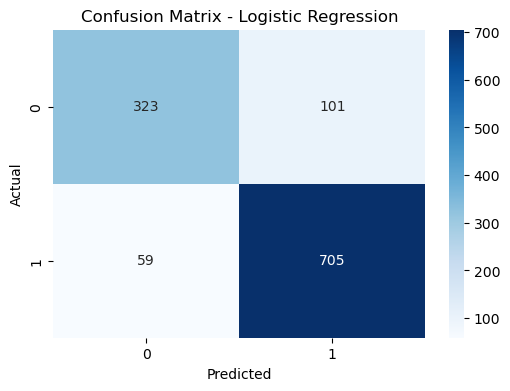

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [39]:
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Random Forest CV Accuracy:", rf_scores.mean())
print("Fold Scores:", rf_scores)

Random Forest CV Accuracy: 0.8797383487508241
Fold Scores: [0.87906137 0.88447653 0.8700361  0.8898917  0.87522604]


In [ ]:
import joblib

joblib.dump(rf_model, "/Users/skush/CodeX/Stress-Level-Classifier/Models/random_forest_87.pkl")

['/Users/skush/CodeX/Stress-Level-Classifier/Models/random_forest_v2_87.pkl']

In [43]:
from sklearn.metrics import roc_auc_score

y_prob = rf_model.predict_proba(X_test_scaled)[:,1]
roc_auc_score(y_test, y_prob)

np.float64(0.8842163266818137)